In [14]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [15]:
# 2013년부터 2016년 현재까지의 데이터 불러오기
query = """
SELECT 
    Actor1CountryCode,
    Actor2CountryCode,
    SQLDATE, 
    EventCode, 
    GoldsteinScale, 
    NumMentions,
    AvgTone,
    IsRootEvent,
    ActionGeo_Type,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE Year BETWEEN 2013 AND 2026
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
"""

# query = """
# SELECT *
# FROM `gdelt-bq.full.events`
# WHERE Year BETWEEN 2013 AND 2026
#   AND (
#     (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
#     (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
#   )
# """

# pandas_gbq를 사용하여 실행
project_id = "project-083a4a68-3ded-4079-8bb" # 로그인창 연결됨
df = pandas_gbq.read_gbq(query, project_id=project_id)

# 결과 확인
print(f"2013년부터 2026년 현재까지 총 {len(df)}건의 데이터를 불러왔습니다.")
display(df.head())

Downloading: 100%|██████████|
2013년부터 2026년 현재까지 총 493317건의 데이터를 불러왔습니다.


,Actor1CountryCode,Actor2CountryCode,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,IsRootEvent,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,TWN,CHN,20170101,011,-0.1,5,-2.191781,1,1,23.5000,121.000,http://www.taipeitimes.com/News/front/archives...
1,TWN,CHN,20170101,071,7.4,1,-5.767669,0,4,39.9289,116.388,http://pakobserver.net/world-in-bitter-transfo...
2,TWN,CHN,20170101,026,4.0,10,-2.307692,1,4,39.9289,116.388,http://borneobulletin.com.bn/taiwan-leader-urg...
3,TWN,CHN,20170101,071,7.4,1,-5.767669,0,4,39.9289,116.388,http://pakobserver.net/world-in-bitter-transfo...
4,TWN,CHN,20170101,027,4.0,1,-2.884615,0,4,39.9289,116.388,http://www.sinodaily.com/reports/Taiwan_wont_c...


In [16]:
# 1. 모든 컬럼명 출력
print(df.columns.tolist())

# 2. 만약 컬럼명이 숫자로 나온다면(0, 1, 2...), 헤더 없이 불러온 것입니다.
# 3. 'geo'가 포함된 컬럼만 검색해보기
geo_cols = [col for col in df.columns if 'geo' in str(col).lower()]
print("지리 관련 컬럼들:", geo_cols)

['Actor1CountryCode', 'Actor2CountryCode', 'SQLDATE', 'EventCode', 'GoldsteinScale', 'NumMentions', 'AvgTone', 'IsRootEvent', 'ActionGeo_Type', 'ActionGeo_Lat', 'ActionGeo_Long', 'SOURCEURL']
지리 관련 컬럼들: ['ActionGeo_Type', 'ActionGeo_Lat', 'ActionGeo_Long']


In [17]:
# 1. 원본 데이터 복사
filtered_df = df.copy()

# 2. 날짜 컬럼 변환 및 기간 필터링 (2013-04-01 ~ 2026-04-30)
filtered_df['EventDate'] = pd.to_datetime(filtered_df['SQLDATE'], format='%Y%m%d')
start_date = '2013-04-01'
end_date = '2026-04-30'
filtered_df = filtered_df[(filtered_df['EventDate'] >= start_date) & (filtered_df['EventDate'] <= end_date)]

# 3. IsRootEvent 피쳐 필터링 (1인 값만)
# 메인 이벤트가 아닌 파생 기사나 중복 정보를 제거하는 단계입니다.
filtered_df = filtered_df[filtered_df['IsRootEvent'] == 1]

# 4. ActionGeo_Type 필터링 (3, 4, 5)
# 3: 주(State), 4: 도시(City), 5: 위경도 좌표 수준의 정밀 데이터만 선택합니다.
filtered_df = filtered_df[filtered_df['ActionGeo_Type'].isin([3, 4, 5])]

# 5. 이벤트 코드 필터링 (15, 19, 20)
# 15: 무력 시위, 19: 무력 사용, 20: 비정규전
filtered_df['EventRootCode'] = filtered_df['EventCode'].astype(str).str.zfill(3).str[:2]
target_codes = ['15', '19', '20']
filtered_df = filtered_df[filtered_df['EventRootCode'].isin(target_codes)]

# 6. 연도(Year) 컬럼 생성 (이후 시각화용)
filtered_df['Year'] = filtered_df['EventDate'].dt.year

# 결과 확인
print(f"--- 필터링 결과 요약 ---")
print(f"최종 데이터 수: {len(filtered_df)}건")
print(f"분석 기간: {filtered_df['EventDate'].min()} ~ {filtered_df['EventDate'].max()}")
print(f"포함된 이벤트 코드: {filtered_df['EventRootCode'].unique()}")
print(f"포함된 Geo 타입: {filtered_df['ActionGeo_Type'].unique()}")

--- 필터링 결과 요약 ---
최종 데이터 수: 11896건
분석 기간: 2013-04-01 00:00:00 ~ 2026-04-30 00:00:00
포함된 이벤트 코드: ['20' '19' '15']
포함된 Geo 타입: <IntegerArray>
[4, 3, 5]
Length: 3, dtype: Int64


In [18]:
columns = ['SQLDATE', 'EventCode', 'GoldsteinScale', 'NumMentions', 'AvgTone', 'IsRootEvent', 'ActionGeo_Type', 'ActionGeo_Lat', 'ActionGeo_Long', 'SOURCEURL']
filtered_df = filtered_df[[col for col in columns]]

In [19]:
filtered_df.head()

,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,IsRootEvent,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
18,20170319,202,-10.0,2,-2.535349,1,4,39.9272,32.8644,https://www.dawn.com/news/1320970/harsh-realities
19,20170319,202,-10.0,6,-2.535349,1,4,39.9272,32.8644,https://www.dawn.com/news/1320970/harsh-realities
23,20170319,202,-10.0,10,-2.535349,1,4,25.0478,121.5320,https://www.dawn.com/news/1320970/harsh-realities
24,20170319,193,-10.0,4,-2.535349,1,4,25.0478,121.5320,https://www.dawn.com/news/1320970/harsh-realities
25,20170319,202,-10.0,2,-2.535349,1,3,38.2024,-122.3040,https://www.dawn.com/news/1320970/harsh-realities


C:\Users\rudak\AppData\Local\Temp\ipykernel_2516\882034696.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = filtered_df.set_index('Date').resample('M').size()


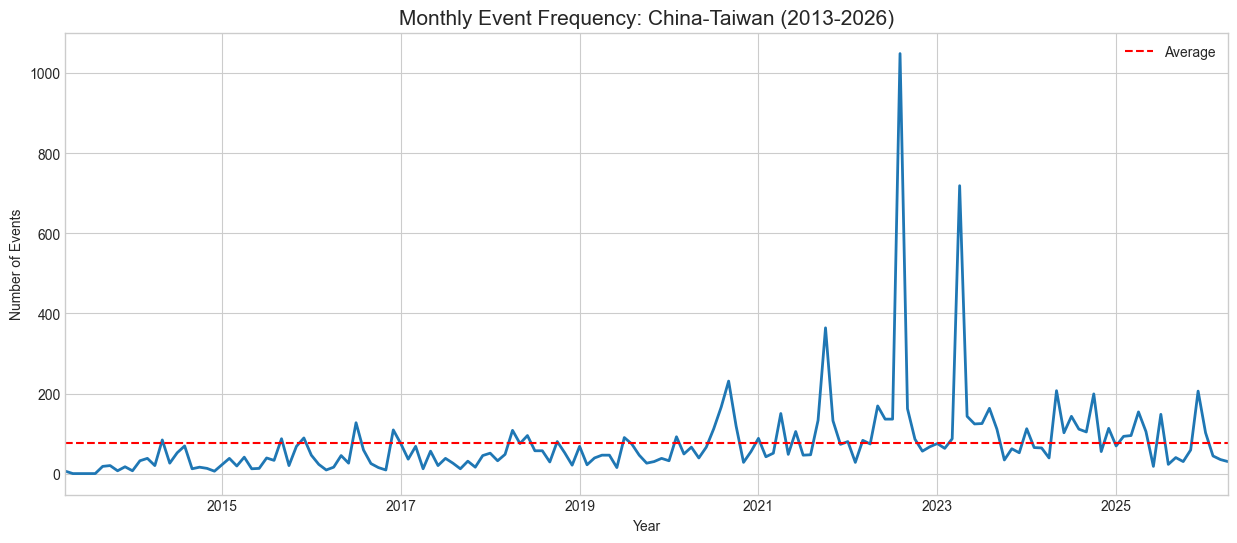

In [20]:
# 1. 날짜 데이터 변환 (Integer -> Datetime)
filtered_df['Date'] = pd.to_datetime(df['SQLDATE'].astype(str), format='%Y%m%d')

# 2. 월별 사건 빈도 계산
monthly_counts = filtered_df.set_index('Date').resample('M').size()

# 3. 시각화
plt.figure(figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid')
monthly_counts.plot(color='#1f77b4', linewidth=2)
plt.title('Monthly Event Frequency: China-Taiwan (2013-2026)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.axhline(monthly_counts.mean(), color='red', linestyle='--', label='Average')
plt.legend()
plt.show()

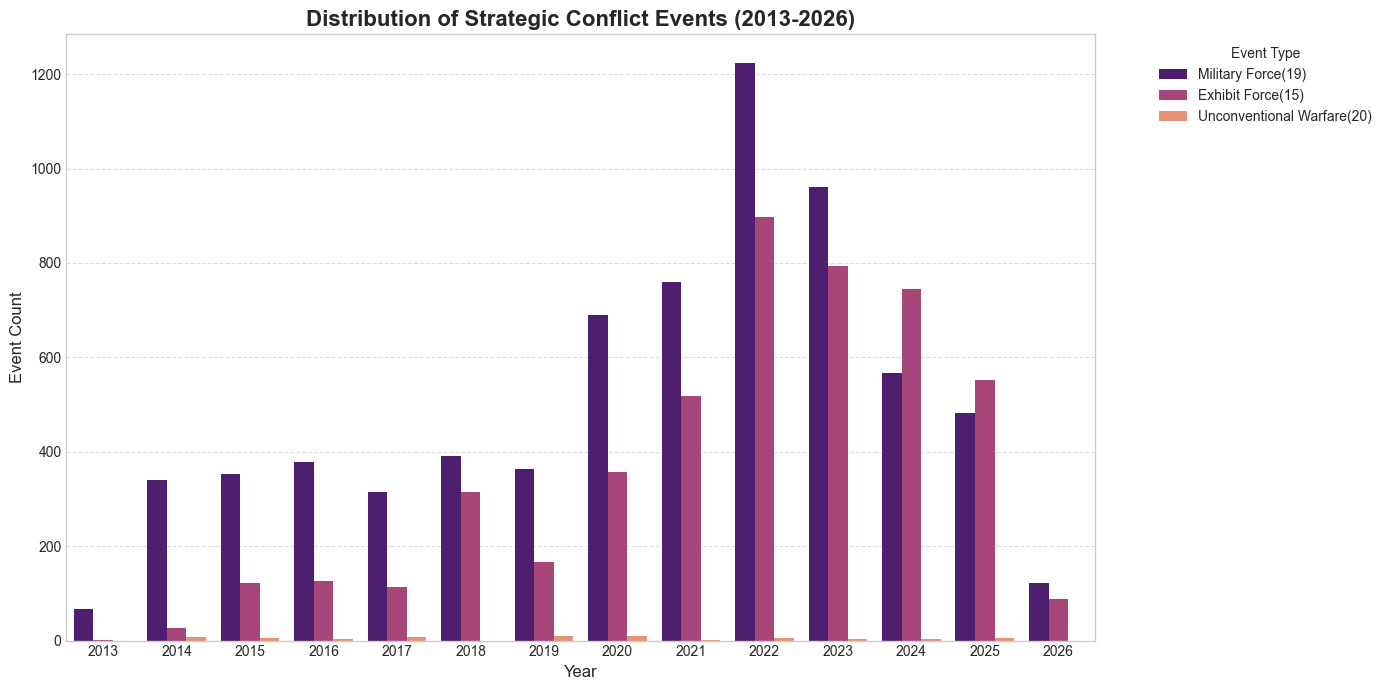

In [21]:
# EventRootCode 추출 (EventCode의 앞 2자리)
filtered_df['EventRootCode'] = filtered_df['EventCode'].astype(str).str.zfill(3).str[:2]

# 3. 사용자 지정 코드 필터링
selected_codes = ['20', '19', '15']
risk_df = filtered_df[filtered_df['EventRootCode'].isin(selected_codes)].copy()

# 1. 시각화용 Year 컬럼 생성 (SQLDATE 활용)
# SQLDATE가 숫자형(20260504)이므로 앞 4자리만 잘라서 연도로 만듭니다.
risk_df['Year'] = risk_df['SQLDATE'].astype(str).str[:4].astype(int)

# 4. 가독성을 위해 코드 번호를 의미로 변환 (Mapping)
code_map = {
    '20': 'Unconventional Warfare(20)',
    '19': 'Military Force(19)',
    '15': 'Exhibit Force(15)',
}
risk_df['EventMeaning'] = risk_df['EventRootCode'].map(code_map)

# 5. 시각화
plt.figure(figsize=(14, 7))
sns.countplot(data=risk_df.sort_values('Year'), x='Year', hue='EventMeaning', palette='magma')

plt.title('Distribution of Strategic Conflict Events (2013-2026)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Event Count', fontsize=12)
plt.legend(title='Event Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

전체 기간 중 탐지된 이상 징후 일수: 100일


,SQLDATE,EventCount,MA14,Is_Anomaly
78,2014-05-15,21,3.142857,True
79,2014-05-16,21,4.571429,True
102,2014-07-07,8,2.500000,True
107,2014-07-24,18,3.785714,True
129,2014-08-27,9,2.571429,True
...,...,...,...,...
2277,2025-09-02,7,2.214286,True
2329,2025-12-05,16,4.285714,True
2347,2025-12-29,47,5.928571,True
2348,2025-12-30,51,9.142857,True


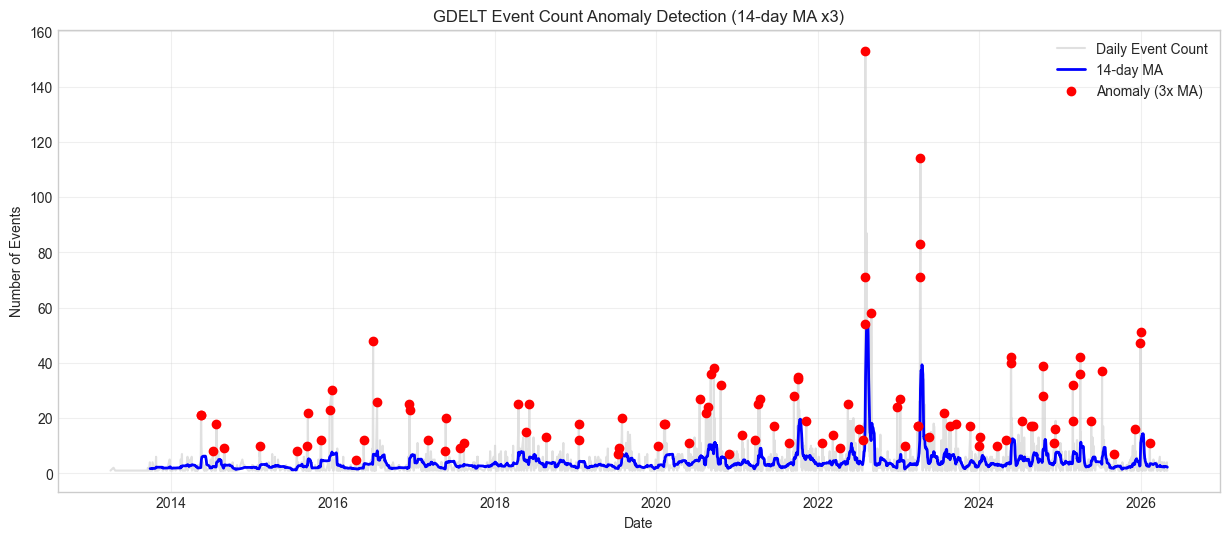

In [22]:
# 1. 날짜 데이터 형식 변환 및 정렬
df_ts = filtered_df.copy()
df_ts['SQLDATE'] = pd.to_datetime(df_ts['SQLDATE'], format='%Y%m%d')

# 2. 일별 기사량(사건 수) 집계
daily_counts = df_ts.groupby('SQLDATE').size().reset_index(name='EventCount')
daily_counts = daily_counts.sort_values('SQLDATE')

# 3. 14일 이동평균(MA14) 계산
daily_counts['MA14'] = daily_counts['EventCount'].rolling(window=14).mean()

# 4. 이상 징후 판별: 당일 기사량 >= (14일 평균 * 3)
# (주의: 앞부분 13일은 평균값이 없으므로 제외)
daily_counts['Is_Anomaly'] = (daily_counts['EventCount'] >= daily_counts['MA14'] * 3) & (daily_counts['MA14'] > 0)

# 5. 이상 징후 데이터만 따로 추출
anomalies = daily_counts[daily_counts['Is_Anomaly']]

print(f"전체 기간 중 탐지된 이상 징후 일수: {len(anomalies)}일")
display(anomalies)

# 6. 시각화 (기사량 추이와 이동평균선, 이상 징후 지점)
plt.figure(figsize=(15, 6))
plt.plot(daily_counts['SQLDATE'], daily_counts['EventCount'], label='Daily Event Count', color='lightgray', alpha=0.7)
plt.plot(daily_counts['SQLDATE'], daily_counts['MA14'], label='14-day MA', color='blue', linewidth=2)
plt.scatter(anomalies['SQLDATE'], anomalies['EventCount'], color='red', label='Anomaly (3x MA)', zorder=5)

plt.title('GDELT Event Count Anomaly Detection (14-day MA x3)')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
# 1. 탐지된 이상 징후 날짜들만 리스트로 추출
anomaly_dates = anomalies['SQLDATE']

# 2. 원본 데이터(df_ts)에서 해당 날짜에 속하는 행들만 필터링
# (df_ts는 위에서 SQLDATE를 datetime 형식으로 바꾼 복사본입니다)
anomaly_details = df_ts[df_ts['SQLDATE'].isin(anomaly_dates)].copy()

# 3. 분석하기 좋게 중요한 컬럼 위주로 정렬하여 확인
# 언급량(NumMentions)이 많은 순서대로 정렬하면 그날의 가장 큰 이슈를 바로 알 수 있습니다.
anomaly_details = anomaly_details.sort_values(by=['SQLDATE', 'NumMentions'], ascending=[True, False])

print(f"이상 징후 발생일의 총 사건 수: {len(anomaly_details)}건")

# 상위 20개 사건의 주요 내용 출력
display(anomaly_details[['SQLDATE', 'EventCode', 'GoldsteinScale', 'NumMentions', 'AvgTone', 'SOURCEURL']].head(20))

이상 징후 발생일의 총 사건 수: 2464건


,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,SOURCEURL
41442,2014-05-15,193,-10.0,274,0.894269,http://www.nation.com.pk/international/16-May-...
487395,2014-05-15,190,-10.0,100,1.833158,http://www.geo.tv/article-147747-China-issues-...
487139,2014-05-15,190,-10.0,20,0.000000,http://www.channelnewsasia.com/news/asiapacifi...
486889,2014-05-15,190,-10.0,17,0.978253,http://www.abc.net.au/news/2014-05-15/an-chine...
487117,2014-05-15,190,-10.0,17,0.000000,http://articles.chicagotribune.com/2014-05-15/...
41877,2014-05-15,193,-10.0,9,1.298701,http://www.nst.com.my/latest/more-than-20-dead...
486469,2014-05-15,190,-10.0,7,0.324675,http://www.trust.org/item/20140515054753-uy3n0/
487109,2014-05-15,190,-10.0,6,0.000000,http://focustaiwan.tw/news/asoc/201405150032.aspx
487373,2014-05-15,190,-10.0,6,2.516779,http://blogs.crikey.com.au/worldisnotenough/20...
487694,2014-05-15,190,-10.0,6,1.627765,http://triblive.com/usworld/world/6122269-74/c...


In [24]:
target_date = "2014-05-15"
day_focus = anomaly_details[anomaly_details['SQLDATE'] == target_date]
display(day_focus)

,SQLDATE,EventCode,GoldsteinScale,NumMentions,AvgTone,IsRootEvent,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL,Date,EventRootCode
41442,2014-05-15,193,-10.0,274,0.894269,1,4,39.9289,116.388,http://www.nation.com.pk/international/16-May-...,2014-05-15,19
487395,2014-05-15,190,-10.0,100,1.833158,1,4,39.9289,116.388,http://www.geo.tv/article-147747-China-issues-...,2014-05-15,19
487139,2014-05-15,190,-10.0,20,0.000000,1,4,15.8500,108.383,http://www.channelnewsasia.com/news/asiapacifi...,2014-05-15,19
486889,2014-05-15,190,-10.0,17,0.978253,1,4,21.0333,105.850,http://www.abc.net.au/news/2014-05-15/an-chine...,2014-05-15,19
487117,2014-05-15,190,-10.0,17,0.000000,1,4,25.0478,121.532,http://articles.chicagotribune.com/2014-05-15/...,2014-05-15,19
41877,2014-05-15,193,-10.0,9,1.298701,1,4,39.9289,116.388,http://www.nst.com.my/latest/more-than-20-dead...,2014-05-15,19
486469,2014-05-15,190,-10.0,7,0.324675,1,4,18.3333,105.900,http://www.trust.org/item/20140515054753-uy3n0/,2014-05-15,19
487109,2014-05-15,190,-10.0,6,0.000000,1,4,25.0478,121.532,http://focustaiwan.tw/news/asoc/201405150032.aspx,2014-05-15,19
487373,2014-05-15,190,-10.0,6,2.516779,1,4,22.0000,105.000,http://blogs.crikey.com.au/worldisnotenough/20...,2014-05-15,19
487694,2014-05-15,190,-10.0,6,1.627765,1,4,39.9289,116.388,http://triblive.com/usworld/world/6122269-74/c...,2014-05-15,19


### 연도별 골드슈타인 지수 합산 결과 ###


,China (CHN),Taiwan (TWN)
Year,,
2013,6631.800000,7155.3
2014,22531.200000,24790.9
2015,31023.400000,34265.6
2016,16039.399999,21706.2
2017,6410.900000,10472.5
2018,4713.400000,8163.4
2019,5574.300000,8571.6
2020,-631.200000,1999.2
2021,-11553.000000,-1723.9


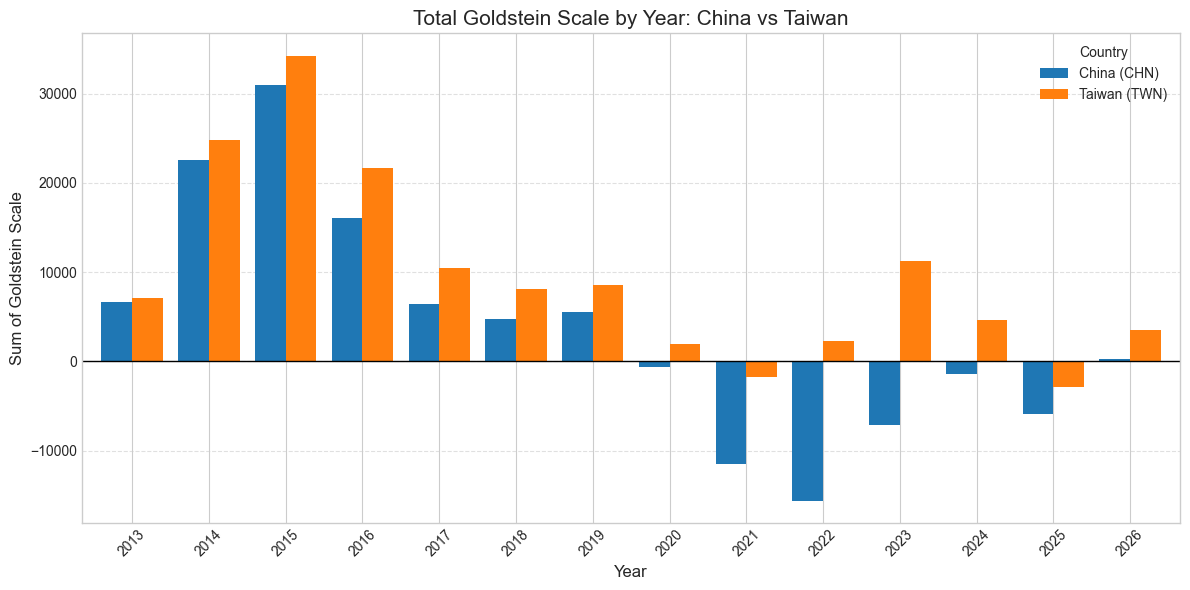

In [25]:
# 1. 연도 정보 추출
df_analysis = df.copy()
df_analysis['Year'] = pd.to_datetime(df_analysis['SQLDATE'], format='%Y%m%d').dt.year

# 2. 국가별(중국 CHN, 대만 TWN) 데이터 분류 및 합산
# Actor1CountryCode 컬럼을 기준으로 분류합니다. (데이터에 따라 Actor1Code일 수 있음)
china_gold = df_analysis[df_analysis['Actor1CountryCode'] == 'CHN'].groupby('Year')['GoldsteinScale'].sum()
taiwan_gold = df_analysis[df_analysis['Actor1CountryCode'] == 'TWN'].groupby('Year')['GoldsteinScale'].sum()

# 3. 데이터 통합 (중국과 대만 데이터를 하나의 표로 합침)
goldstein_yearly = pd.DataFrame({
    'China (CHN)': china_gold,
    'Taiwan (TWN)': taiwan_gold
}).fillna(0) # 데이터가 없는 연도는 0으로 처리

print("### 연도별 골드슈타인 지수 합산 결과 ###")
display(goldstein_yearly)

# 4. 시계열 막대 그래프 시각화
ax = goldstein_yearly.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Total Goldstein Scale by Year: China vs Taiwan', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sum of Goldstein Scale', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Country')

# 0선을 기준으로 위(협력)와 아래(갈등)를 명확히 구분하기 위해 수평선 추가
plt.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

### 연도별 AvgTone 합산 결과 ###


,China (AvgTone Sum),Taiwan (AvgTone Sum)
Year,,
2013,9503.246605,10228.852663
2014,36051.043019,37459.454175
2015,-8315.406474,-7208.306635
2016,-38801.766727,-38012.361066
2017,-24086.707582,-21941.394688
2018,-21575.160732,-17172.611344
2019,-23484.828167,-22329.057107
2020,-44533.627662,-42937.525330
2021,-47915.204738,-35767.107186


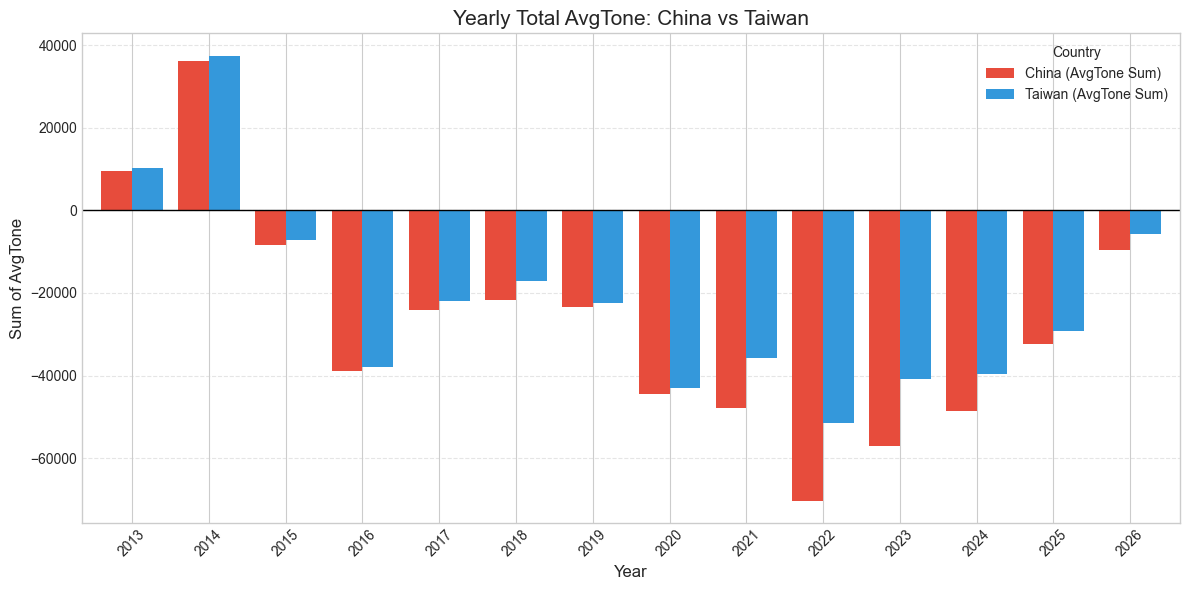

In [30]:
# 1. 데이터 복사 및 연도 추출
df_tone = df.copy()
df_year_tone = df_tone.copy()
df_year_tone['Year'] = pd.to_datetime(df_year_tone['SQLDATE'], format='%Y%m%d').dt.year

# 2. 국가별(CHN, TWN) 데이터 분류 및 AvgTone 합산
# Actor1Code에 CHN이나 TWN이 포함된 행을 찾아 연도별로 AvgTone을 더합니다.
china_tone = df_year_tone[df_year_tone['Actor1CountryCode'].str.contains('CHN', na=False)].groupby('Year')['AvgTone'].sum()
taiwan_tone = df_year_tone[df_year_tone['Actor1CountryCode'].str.contains('TWN', na=False)].groupby('Year')['AvgTone'].sum()

# 3. 데이터프레임 통합
tone_yearly = pd.DataFrame({
    'China (AvgTone Sum)': china_tone,
    'Taiwan (AvgTone Sum)': taiwan_tone
}).fillna(0)

print("### 연도별 AvgTone 합산 결과 ###")
display(tone_yearly)

# 4. 시각화
ax = tone_yearly.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#e74c3c', '#3498db'])
plt.title('Yearly Total AvgTone: China vs Taiwan', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sum of AvgTone', fontsize=12)
plt.axhline(0, color='black', linewidth=1) # 0점 기준선 (긍정/부정 경계)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(title='Country')

plt.tight_layout()
plt.show()

In [31]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd
import numpy as np

# 1. 좌표별로 그룹화하여 AvgTone과 GoldsteinScale 합산
# 좌표가 없는 데이터는 제외합니다.
geo_summary = filtered_df.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long']).groupby(
    ['ActionGeo_Lat', 'ActionGeo_Long']
).agg({
    'AvgTone': 'sum',
    'GoldsteinScale': 'sum',
    'NumMentions': 'sum' # 버블 크기 결정을 위해 언급량 합산도 추가
}).reset_index()

# 2. 지도 생성 (대만/중국 중심부)
m_geo = folium.Map(location=[23.6978, 120.9605], zoom_start=5, tiles='CartoDB positron')

# 3. 좌표별 마커 추가
for idx, row in geo_summary.iterrows():
    # Goldstein 지수가 음수이면 빨간색(갈등), 양수이면 파란색(협력)
    color = 'crimson' if row['GoldsteinScale'] < 0 else 'royalblue'
    
    # 언급량에 따라 버블 크기 조절 (최소 3, 최대 30)
    radius = np.clip(row['NumMentions'] / 20, 3, 30)
    
    popup_html = f"""
    <div style="width:200px">
        <b>Location:</b> {row['ActionGeo_Lat']:.2f}, {row['ActionGeo_Long']:.2f}<br><br>
        <b>Total AvgTone:</b> <span style="color:{'red' if row['AvgTone'] < 0 else 'blue'}">{row['AvgTone']:.2f}</span><br>
        <b>Total Goldstein:</b> <span style="color:{'red' if row['GoldsteinScale'] < 0 else 'blue'}">{row['GoldsteinScale']:.2f}</span><br>
        <b>Total Mentions:</b> {int(row['NumMentions'])}
    </div>
    """
    
    folium.CircleMarker(
        location=[row['ActionGeo_Lat'], row['ActionGeo_Long']],
        radius=radius,
        popup=folium.Popup(popup_html, max_width=300),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6
    ).add_to(m_geo)

# 4. 지도 저장 및 확인
m_geo.save('geo_sentiment_map.html')
m_geo

In [33]:
# 1. 데이터 타입 이슈 해결을 위해 EventCode를 문자열로 통일하여 복사
df_check = df.copy()
df_check['EventCode_str'] = df_check['EventCode'].astype(str).str.zfill(4)
df_check['RootCode'] = df_check['EventCode_str'].str[:2]

# 2. 대상 코드 설정 (15, 19, 20)
# 문자열 리스트로 비교하여 타입 불일치 방지
target_mil_codes = ['15', '19', '20']

# 3. 필터링 실행
# 'RootCode'가 target_mil_codes에 포함된 행만 추출
mil_events = df_check[df_check['RootCode'].isin(target_mil_codes)].copy()

# 4. 결과 확인 및 디버깅 정보 출력
print(f"전체 데이터 수: {len(df_check)}건")
print(f"군사 관련 코드(15, 19, 20) 탐지 수: {len(mil_events)}건")

if len(mil_events) == 0:
    print("\n[알림] 탐지된 값이 없습니다. 원인 확인을 위해 데이터의 RootCode 분포를 출력합니다:")
    print(df_check['RootCode'].value_counts().head(10))
else:
    # 좌표 데이터가 있는 것만 골라 위험 점수 계산
    mil_events = mil_events.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long'])
    mil_events['Risk_Score'] = mil_events['NumMentions'] * mil_events['GoldsteinScale'].abs()
    
    # 결과 출력
    display(mil_events[['SQLDATE', 'EventCode', 'ActionGeo_Lat', 'ActionGeo_Long', 'Risk_Score']].head(10))

전체 데이터 수: 493317건
군사 관련 코드(15, 19, 20) 탐지 수: 0건

[알림] 탐지된 값이 없습니다. 원인 확인을 위해 데이터의 RootCode 분포를 출력합니다:
RootCode
00    330489
01    150865
08      3539
03      2727
10      1843
17      1154
13      1069
02       882
11       454
12       142
Name: count, dtype: int64


### [공간 분석] 위성 관측 최우선 순위 지역 (Top 5) ###


,ActionGeo_Lat,ActionGeo_Long,Risk_Score,EventCode


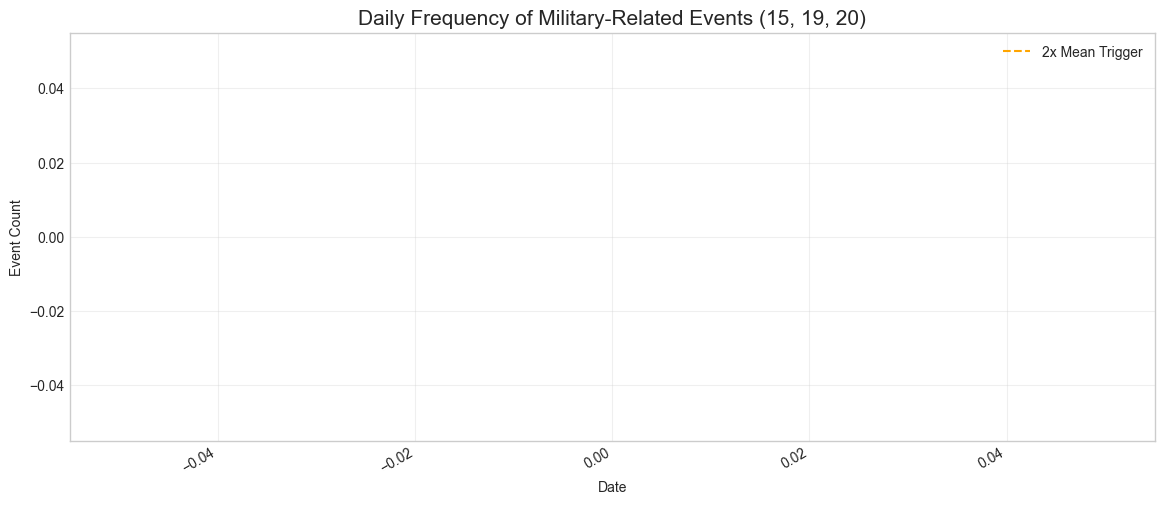

In [32]:
# 1. 데이터 필터링 (15: Mobilize, 19: Fight, 20: Unconventional Mass Violence)
target_codes = ['15', '19', '20']

# EventCode의 앞 2자리를 추출하여 RootCode 생성
df_mil = df.copy()
df_mil['RootCode'] = df_mil['EventCode'].astype(str).str.zfill(4).str[:2]

# 15, 19, 20번 코드만 필터링
df_mil_filtered = df_mil[df_mil['RootCode'].isin(target_codes)].copy()

# 좌표 데이터가 없는 행 제거
df_mil_filtered = df_mil_filtered.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long'])

# 2. 분석 가중치 설정 (Risk Score)
# 언급량(NumMentions)과 사건의 파급력(GoldsteinScale 절대값)을 곱해 실제 지상 변화 가능성이 높은 지수를 산출합니다.
df_mil_filtered['Risk_Score'] = df_mil_filtered['NumMentions'] * df_mil_filtered['GoldsteinScale'].abs()

# 3. 공간 분석: 위성 관측 우선순위 좌표(ROI) 도출
# 같은 좌표에서 발생하는 리스크 점수를 합산하여 상위 지역 추출
roi_analysis = df_mil_filtered.groupby(['ActionGeo_Lat', 'ActionGeo_Long']).agg({
    'Risk_Score': 'sum',
    'EventCode': 'count'
}).sort_values(by='Risk_Score', ascending=False).reset_index()

print("### [공간 분석] 위성 관측 최우선 순위 지역 (Top 5) ###")
display(roi_analysis.head(5))

# 4. 시간 분석: 이상 징후 발생 시점 탐지 (위성 촬영 타이밍)
df_mil_filtered['SQLDATE'] = pd.to_datetime(df_mil_filtered['SQLDATE'], format='%Y%m%d')
daily_mil_trend = df_mil_filtered.groupby('SQLDATE').size()

# 5. 시각화: 군사 행동 빈도 추이
plt.figure(figsize=(14, 6))
daily_mil_trend.plot(kind='line', color='darkred', marker='x', markersize=4, linewidth=1.5)
plt.title('Daily Frequency of Military-Related Events (15, 19, 20)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Event Count')
plt.grid(True, alpha=0.3)

# 평균 대비 급증한 시점을 강조 (위성 촬영 트리거 시점)
mean_val = daily_mil_trend.mean()
plt.axhline(mean_val * 2, color='orange', linestyle='--', label='2x Mean Trigger')
plt.legend()
plt.show()